# **Dollar Edition Analysis**

This notebook starts from a blank state and builds Chart 1 using live data.

Data sources used:
- FRED: Trade Weighted U.S. Dollar Index (Broad)
- WorldGovernmentBonds: United States 5Y CDS historical series

In [1]:
import sys
print("✓ Kernel OK, Python", sys.version_info.major, ".", sys.version_info.minor)

✓ Kernel OK, Python 3 . 13


Loaded 2154 rows
Saved PNG: chart1_dxy_cds_divergence.png


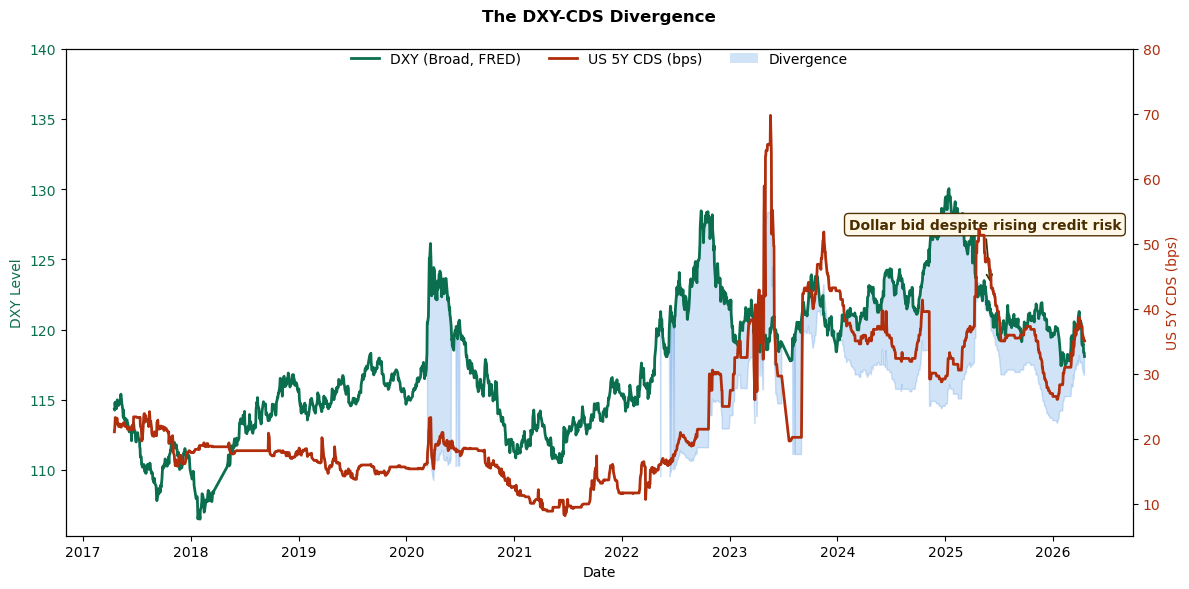

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import requests
from pandas_datareader import data as pdr
import numpy as np

START_DATE = "2017-01-01"

def fetch_dxy_fred(start_date: str = START_DATE) -> pd.DataFrame:
    dxy = pdr.DataReader("DTWEXBGS", "fred", start_date)
    dxy = dxy.rename(columns={"DTWEXBGS": "dxy"})
    return dxy

def fetch_us_5y_cds_wgb(timeout: int = 10) -> pd.DataFrame:
    url = "https://www.worldgovernmentbonds.com/wp-json/common/v1/historical"
    headers = {
        "Content-Type": "application/json",
        "Origin": "https://www.worldgovernmentbonds.com",
        "Referer": "https://www.worldgovernmentbonds.com/cds-historical-data/united-states/5-years/",
    }
    globalvar = {
        "JS_VARIABLE": "jsGlobalVars",
        "FUNCTION": "CDS",
        "DOMESTIC": True,
        "ENDPOINT": url,
        "DATE_RIF": "2099-12-31",
        "DEBUG": True,
        "OBJ": {"UNIT": "", "DECIMAL": 2, "UNIT_DELTA": "%", "DECIMAL_DELTA": 2},
        "COUNTRY1": {
            "SYMBOL": "6",
            "PAESE": "United States",
            "PAESE_UPPERCASE": "UNITED STATES",
            "BANDIERA": "us",
            "URL_PAGE": "united-states",
        },
        "COUNTRY2": None,
        "OBJ1": {"DURATA_STRING": "5 Years", "DURATA": 60},
        "OBJ2": None,
    }

    resp = requests.post(url, json={"GLOBALVAR": globalvar}, headers=headers, timeout=timeout)
    resp.raise_for_status()
    quote = resp.json()["result"]["quote"]

    recs = []
    for idx, item in quote.items():
        if isinstance(item, dict) and "CLOSE_VAL" in item and "DATA_VAL" in item:
            recs.append({
                "date": item["DATA_VAL"],
                "value": item["CLOSE_VAL"]
            })

    cds = pd.DataFrame(recs)
    cds["date"] = pd.to_datetime(cds["date"], format="%Y-%m-%d", errors="coerce")
    cds["value"] = pd.to_numeric(cds["value"], errors="coerce")
    cds = cds.dropna(subset=["date", "value"]).sort_values("date")
    cds = cds.rename(columns={"value": "us_5y_cds_bps"}).set_index("date")
    return cds

# Fetch data
dxy = fetch_dxy_fred()
cds = fetch_us_5y_cds_wgb()

# Build chart1
chart1 = dxy.join(cds, how="inner").dropna().copy()
chart1["dxy_z"] = (chart1["dxy"] - chart1["dxy"].mean()) / chart1["dxy"].std()
chart1["cds_z"] = (chart1["us_5y_cds_bps"] - chart1["us_5y_cds_bps"].mean()) / chart1["us_5y_cds_bps"].std()
chart1["dxy_cds_divergence"] = chart1["dxy_z"] + chart1["cds_z"]

print(f"Loaded {len(chart1)} rows")

# Plot
if len(chart1) > 0:
    plot_df = chart1.dropna(subset=["dxy", "us_5y_cds_bps", "dxy_cds_divergence"]).copy()

    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2 = ax1.twinx()

    # DXY on left axis (green)
    line1, = ax1.plot(plot_df.index, plot_df["dxy"], color="#0B6E4F", linewidth=2.0, label="DXY (Broad, FRED)", zorder=2)
    ax1.set_ylabel("DXY Level", color="#0B6E4F")
    ax1.tick_params(axis="y", labelcolor="#0B6E4F")

    # CDS on right axis (red)
    line2, = ax2.plot(plot_df.index, plot_df["us_5y_cds_bps"], color="#B02E0C", linewidth=2.0, label="US 5Y CDS (bps)", zorder=2)
    ax2.set_ylabel("US 5Y CDS (bps)", color="#B02E0C")
    ax2.tick_params(axis="y", labelcolor="#B02E0C")

    # Transform CDS values to DXY coordinate system for fill_between
    dxy_min, dxy_max = ax1.get_ylim() if ax1.get_ylim()[1] > 0 else (ax1.dataLim.ymin, ax1.dataLim.ymax)
    cds_min, cds_max = ax2.get_ylim() if ax2.get_ylim()[1] > 0 else (ax2.dataLim.ymin, ax2.dataLim.ymax)

    # Linear transform from CDS axis to DXY axis
    cds_transformed = dxy_min + (plot_df["us_5y_cds_bps"] - cds_min) / (cds_max - cds_min) * (dxy_max - dxy_min)

    # Fill between the two lines where divergence is positive
    ax1.fill_between(plot_df.index, plot_df["dxy"], cds_transformed,
                     where=(plot_df["dxy_cds_divergence"] > 0),
                     color="#4A90E2", alpha=0.25, zorder=1, interpolate=True)

    # Annotation only (no additional zone highlight)

    anchor_date = pd.Timestamp("2025-06-01")
    anchor_idx = plot_df.index.get_indexer([anchor_date], method="nearest")[0]
    callout_x = plot_df.index[anchor_idx]
    callout_y = min(float(plot_df["dxy"].iloc[anchor_idx]) + 2.0, 136)
    ax1.annotate(
        "Dollar bid despite rising credit risk",
        xy=(callout_x, callout_y),
        xytext=(callout_x - pd.Timedelta(days=480), callout_y + 4.0),
        fontsize=10,
        fontweight="bold",
        color="#4B2E00",
        arrowprops=dict(arrowstyle="->", color="#4B2E00", lw=1.3),
        bbox=dict(boxstyle="round,pad=0.3", fc="#FFF8E8", ec="#4B2E00", alpha=0.97),
        zorder=4,
    )

    ax1.set_title("The DXY-CDS Divergence", pad=20, fontweight='bold')
    ax1.set_xlabel("Date")
    ax1.grid(False)
    ax1.set_axisbelow(True)

    # Set axis limits
    ax1.set_ylim(None, 140)
    ax2.set_ylim(None, 80)

    # Legend centered at top
    shade_patch = Patch(facecolor="#4A90E2", alpha=0.25, label="Divergence")
    ax1.legend(handles=[line1, line2, shade_patch], loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)

    plt.tight_layout()
    chart1_png = "chart1_dxy_cds_divergence.png"
    fig.savefig(chart1_png, dpi=300, bbox_inches="tight")
    print(f"Saved PNG: {chart1_png}")
    plt.show()
else:
    print("No overlapping data")

## **Chart 2**

Chart 2 source: Network (Yahoo, multi-series)
Loaded 4766 observations
Saved PNG: chart2_cross_currency_basis.png


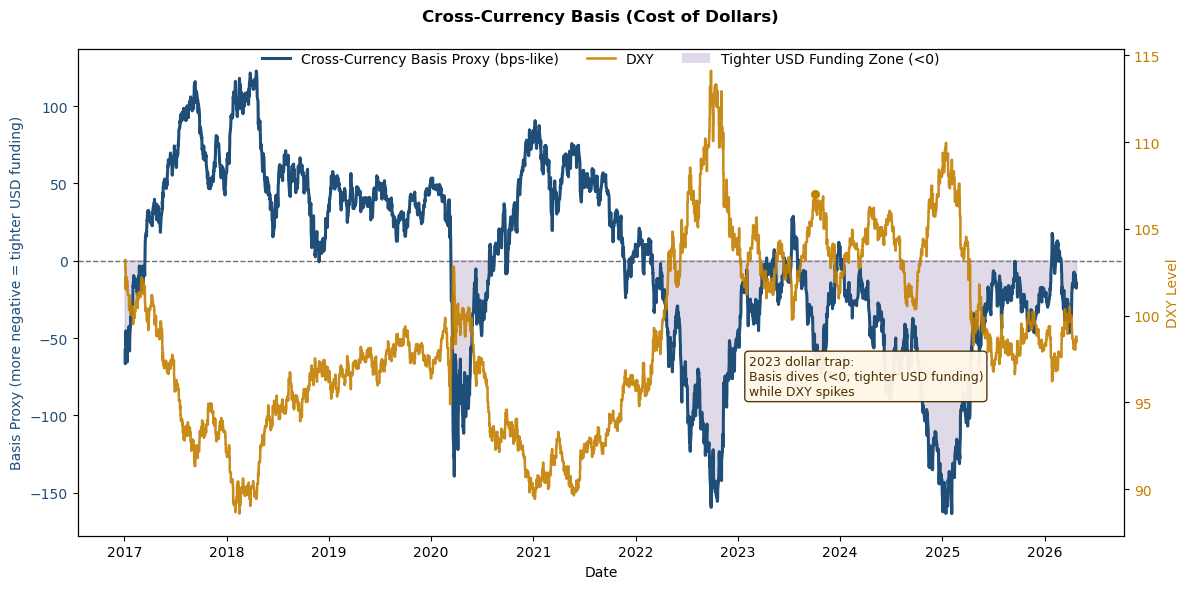

In [5]:
# Chart 2: Cross-Currency Basis Proxy (The Cost of Dollars)
# Remote data only (Yahoo API), bounded-time to avoid endless execution.

import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

START = "2017-01-01"
DEADLINE_SECONDS = 8
PER_REQUEST_TIMEOUT = 2


def fetch_yahoo_close_fast(symbol: str, start: str, timeout_sec: int = PER_REQUEST_TIMEOUT) -> pd.Series:
    period1 = int(pd.Timestamp(start, tz="UTC").timestamp())
    period2 = int(pd.Timestamp.utcnow().timestamp())
    url = (
        f"https://query1.finance.yahoo.com/v8/finance/chart/{symbol}"
        f"?period1={period1}&period2={period2}&interval=1d&events=history"
    )

    r = requests.get(url, timeout=timeout_sec, headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()
    payload = r.json()

    result = payload.get("chart", {}).get("result", [])
    if not result:
        raise ValueError(f"No data for {symbol}")

    ts = result[0].get("timestamp", [])
    q = result[0].get("indicators", {}).get("quote", [{}])[0]
    close = q.get("close", [])

    if not ts or not close:
        raise ValueError(f"Malformed data for {symbol}")

    s = pd.Series(
        close,
        index=pd.to_datetime(ts, unit="s", utc=True).tz_convert(None),
        dtype="float64",
    ).dropna()
    s.name = symbol
    return s


def build_network_proxy(start_date: str):
    symbols = {
        "DXY": "DX-Y.NYB",
        "USDJPY": "JPY=X",
        "USDMXN": "MXN=X",
    }

    t0 = time.monotonic()
    series = {}
    errors = []

    for label, symbol in symbols.items():
        if time.monotonic() - t0 > DEADLINE_SECONDS:
            errors.append("Hit network deadline; using available series")
            break
        try:
            series[label] = fetch_yahoo_close_fast(symbol, start_date)
        except Exception as e:
            errors.append(f"{label}: {e}")

    if len(series) < 3:
        raise RuntimeError("Insufficient remote series")

    df = pd.DataFrame(series).dropna(how="all").ffill().dropna()
    z = (df - df.mean()) / df.std(ddof=0)
    usd_stress = z.mean(axis=1)
    basis_proxy = -(usd_stress - usd_stress.median()) * 100

    out = pd.DataFrame({
        "basis_proxy": basis_proxy,
        "DXY": df["DXY"] if "DXY" in df.columns else df.iloc[:, 0],
    }).dropna()

    return out, errors


def build_single_series_proxy(start_date: str):
    # Remote fallback: only one liquid series required.
    dxy = fetch_yahoo_close_fast("DX-Y.NYB", start_date)
    dxy_z = (dxy - dxy.mean()) / dxy.std(ddof=0)
    basis_proxy = -(dxy_z - dxy_z.median()) * 100
    out = pd.DataFrame({"basis_proxy": basis_proxy, "DXY": dxy}).dropna()
    return out


source_used = "Network (Yahoo, multi-series)"
notes = []

try:
    chart2, notes = build_network_proxy(START)
except Exception as e1:
    notes.append(f"multi-series failed: {e1}")
    try:
        source_used = "Network (Yahoo, DXY-only fallback)"
        chart2 = build_single_series_proxy(START)
    except Exception as e2:
        notes.append(f"DXY-only failed: {e2}")
        raise RuntimeError(
            "Chart 2 failed: remote Yahoo data unavailable. "
            "Check internet access and rerun Cell 5."
        )

print(f"Chart 2 source: {source_used}")
print(f"Loaded {len(chart2)} observations")
if notes:
    print("Notes:")
    for n in notes[:3]:
        print(f"- {n}")

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

line_basis, = ax1.plot(
    chart2.index,
    chart2["basis_proxy"],
    color="#1F4E79",
    linewidth=2.2,
    label="Cross-Currency Basis Proxy (bps-like)",
    zorder=3,
)

ax1.axhline(0, color="#333333", linestyle="--", linewidth=1.0, alpha=0.7, zorder=1)
ax1.fill_between(
    chart2.index,
    chart2["basis_proxy"],
    0,
    where=(chart2["basis_proxy"] < 0),
    color="#9C89B8",
    alpha=0.32,
    interpolate=True,
    zorder=2,
)

line_dxy, = ax2.plot(
    chart2.index,
    chart2["DXY"],
    color="#C47F00",
    linewidth=1.8,
    label="DXY",
    alpha=0.9,
    zorder=2,
)

# 2023 stress annotation: visual proof of the dollar trap thesis.
stress_2023 = chart2.loc["2023-01-01":"2023-12-31"]
if not stress_2023.empty:
    basis_min_date = stress_2023["basis_proxy"].idxmin()
    basis_min_val = float(stress_2023.loc[basis_min_date, "basis_proxy"])
    dxy_peak_date = stress_2023["DXY"].idxmax()
    dxy_peak_val = float(stress_2023.loc[dxy_peak_date, "DXY"])

    ax1.annotate(
        "2023 dollar trap:\nBasis dives (<0, tighter USD funding)\nwhile DXY spikes",
        xy=(basis_min_date, basis_min_val),
        xytext=(basis_min_date - pd.Timedelta(days=260), basis_min_val - 14),
        fontsize=9,
        color="#4B2E00",
        arrowprops=dict(arrowstyle="->", color="#4B2E00", lw=1.2),
        bbox=dict(boxstyle="round,pad=0.3", fc="#FFF8E8", ec="#4B2E00", alpha=0.95),
        zorder=5,
    )
    ax2.scatter([dxy_peak_date], [dxy_peak_val], color="#C47F00", s=30, zorder=4)

ax1.set_title("Cross-Currency Basis (Cost of Dollars)", pad=20, fontweight="bold")
ax1.set_xlabel("Date")
ax1.set_ylabel("Basis Proxy (more negative = tighter USD funding)", color="#1F4E79")
ax2.set_ylabel("DXY Level", color="#C47F00")
ax1.tick_params(axis="y", labelcolor="#1F4E79")
ax2.tick_params(axis="y", labelcolor="#C47F00")
ax1.grid(False)
ax1.set_axisbelow(True)

shade_patch = Patch(facecolor="#9C89B8", alpha=0.32, label="Tighter USD Funding Zone (<0)")

ax1.legend(
    handles=[line_basis, line_dxy, shade_patch],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False,
)

plt.tight_layout()
chart2_png = "chart2_cross_currency_basis.png"
fig.savefig(chart2_png, dpi=300, bbox_inches="tight")
print(f"Saved PNG: {chart2_png}")
plt.show()

Chart 1 (DXY vs. US CDS): Sources: FRED (Federal Reserve Economic Data, series `DTWEXBGS`) and WorldGovernmentBonds.com historical API (United States 5Y CDS).

Chart 2 (Cross-Currency Basis Proxy): Source: Yahoo Finance chart API (`query1.finance.yahoo.com`) using `DX-Y.NYB` (DXY), `JPY=X` (USD/JPY), `MXN=X` (USD/MXN), `BRL=X` (USD/BRL), and `ZAR=X` (USD/ZAR).